# Multi-Resolution Clustering with PLSCAN

One of the trickiest aspects of using HDBSCAN is choosing the ``min_cluster_size`` parameter. Different values can
reveal very different structure in your data, and it's not always clear which resolution is the "right" one.
``fast_hdbscan`` provides the ``PLSCAN`` class which automates this process entirely. PLSCAN finds all meaningful
clustering resolutions in your data, ranks them by a persistence score, and returns the best one -- along with
all the other layers for you to explore. It implements the algorithm described in
[Persistent Multiscale Density-based Clustering](https://arxiv.org/abs/2512.16558). Let's load some libraries and
grab some data to see it in action:

In [1]:
import numpy as np
import fast_hdbscan

import requests
from io import BytesIO
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

sns.set(rc={"figure.figsize":(8,8)})
data_request = requests.get(
    "https://github.com/scikit-learn-contrib/hdbscan/blob/master/notebooks/clusterable_data.npy?raw=true"
)
data = np.load(BytesIO(data_request.content))

This is the same dataset used in the [basic usage](basic_usage.ipynb) notebook. Before we cluster, let's plot it so we can see what we're working with:

<Axes: >

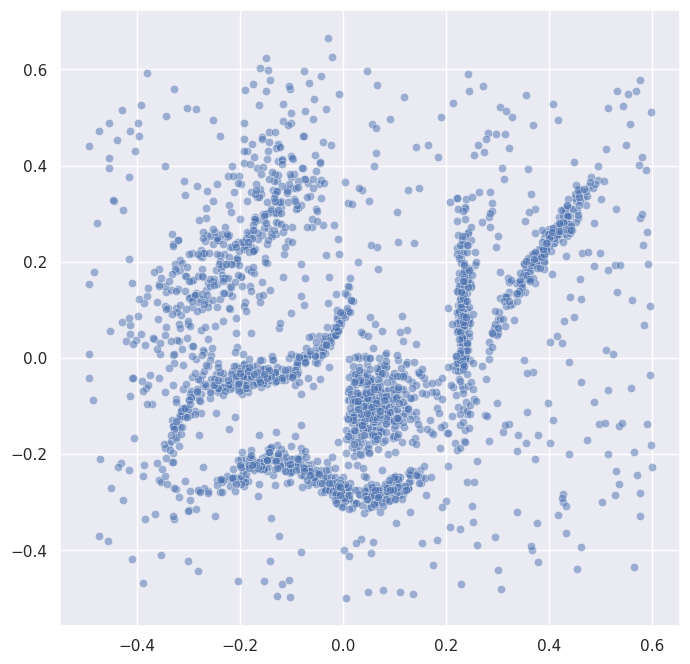

In [2]:
sns.scatterplot(x=data.T[0], y=data.T[1], alpha=0.5)

## The resolution problem

Let's illustrate why choosing ``min_cluster_size`` can be tricky. We'll run HDBSCAN with two very different values and see what happens:

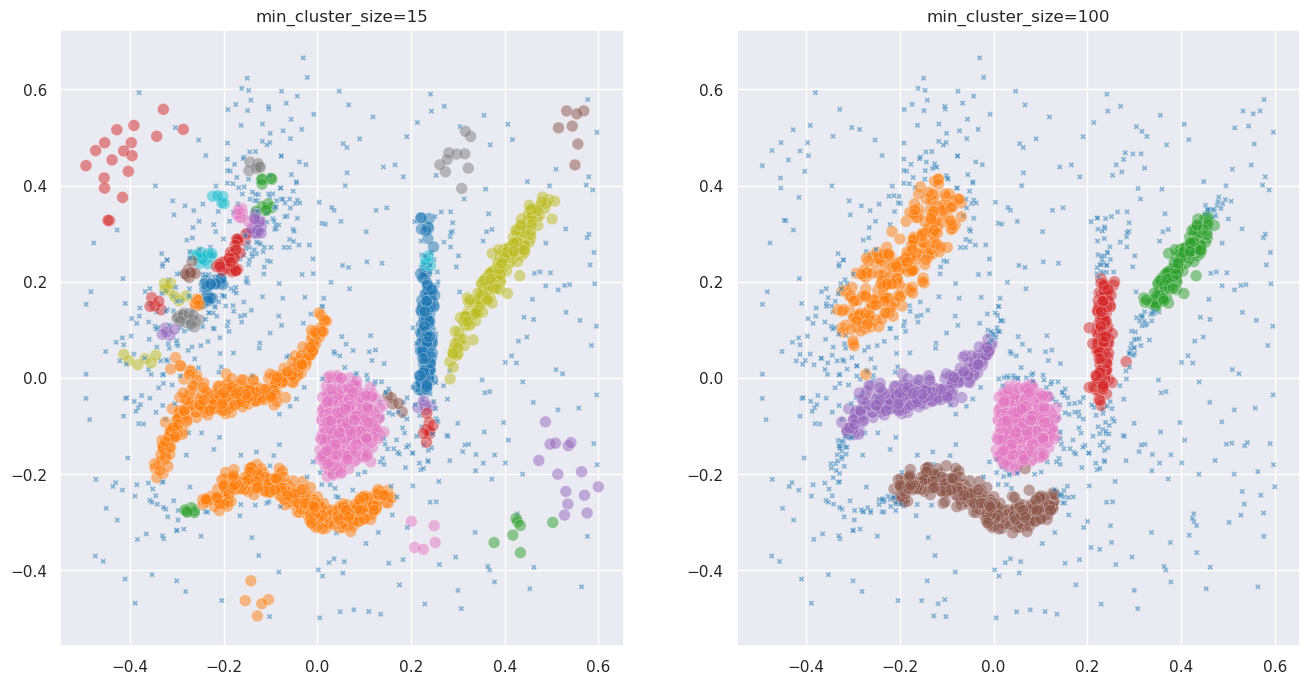

In [3]:
labels_fine = fast_hdbscan.HDBSCAN(min_cluster_size=5).fit_predict(data)
labels_coarse = fast_hdbscan.HDBSCAN(min_cluster_size=50).fit_predict(data)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, labels, title in zip(
    axes,
    [labels_fine, labels_coarse],
    ["min_cluster_size=15", "min_cluster_size=100"],
):
    sns.scatterplot(
        x=data.T[0], y=data.T[1], alpha=0.5,
        hue=labels, style=labels < 0, size=labels < 0,
        palette="tab10", legend=False, ax=ax,
    )
    ax.set_title(title)

Different values of ``min_cluster_size`` reveal different structure. Which is the right answer? It depends on what you're looking for -- and choosing can feel like guesswork. PLSCAN finds all meaningful resolutions automatically, with almost no parameter tuning.

## Basic PLSCAN usage

Using ``PLSCAN`` is as simple as using ``HDBSCAN``. You create a ``PLSCAN`` object and call ``fit_predict`` on your data. The default parameters work well for most datasets:

In [4]:
clusterer = fast_hdbscan.PLSCAN()
labels = clusterer.fit_predict(data)

The ``labels_`` attribute gives you the best clustering -- the layer with the highest persistence score. Let's plot it:

<Axes: >

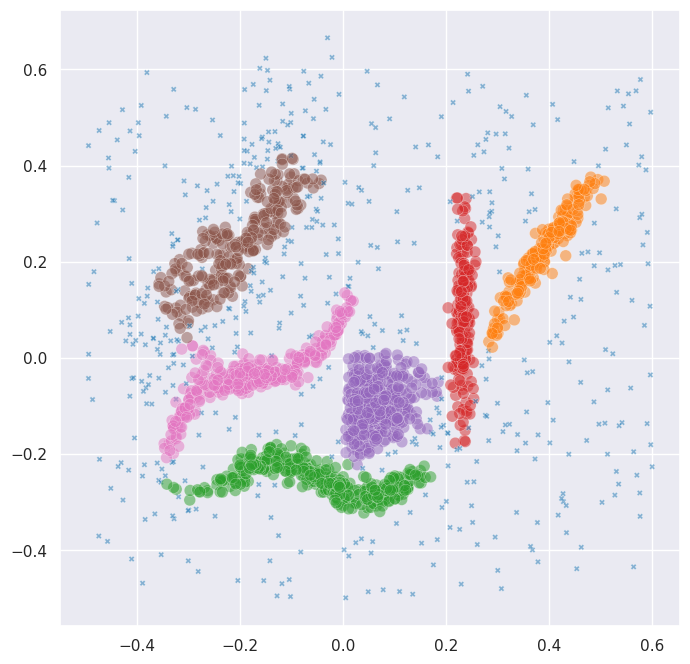

In [5]:
sns.scatterplot(
    x=data.T[0], y=data.T[1], alpha=0.5,
    hue=clusterer.labels_, style=clusterer.labels_ < 0, size=clusterer.labels_ < 0,
    palette="tab10", legend=False,
)

With no parameter tuning at all, PLSCAN found a good clustering of the data.

## Exploring the layers

PLSCAN doesn't just give you one clustering -- it finds all meaningful resolutions. These are stored in the ``cluster_layers_`` attribute. Each layer is an array of cluster labels at a different resolution. Let's see how many layers PLSCAN found and what their persistence scores are:

In [6]:
print(f"Number of layers: {len(clusterer.cluster_layers_)}")
print(f"Persistence scores: {clusterer.layer_persistence_scores_}")

Number of layers: 4
Persistence scores: [0.0, np.float32(752.7444), np.float32(1556.6232), np.float32(1452.8157)]


Let's plot each layer so we can see what resolutions PLSCAN identified:

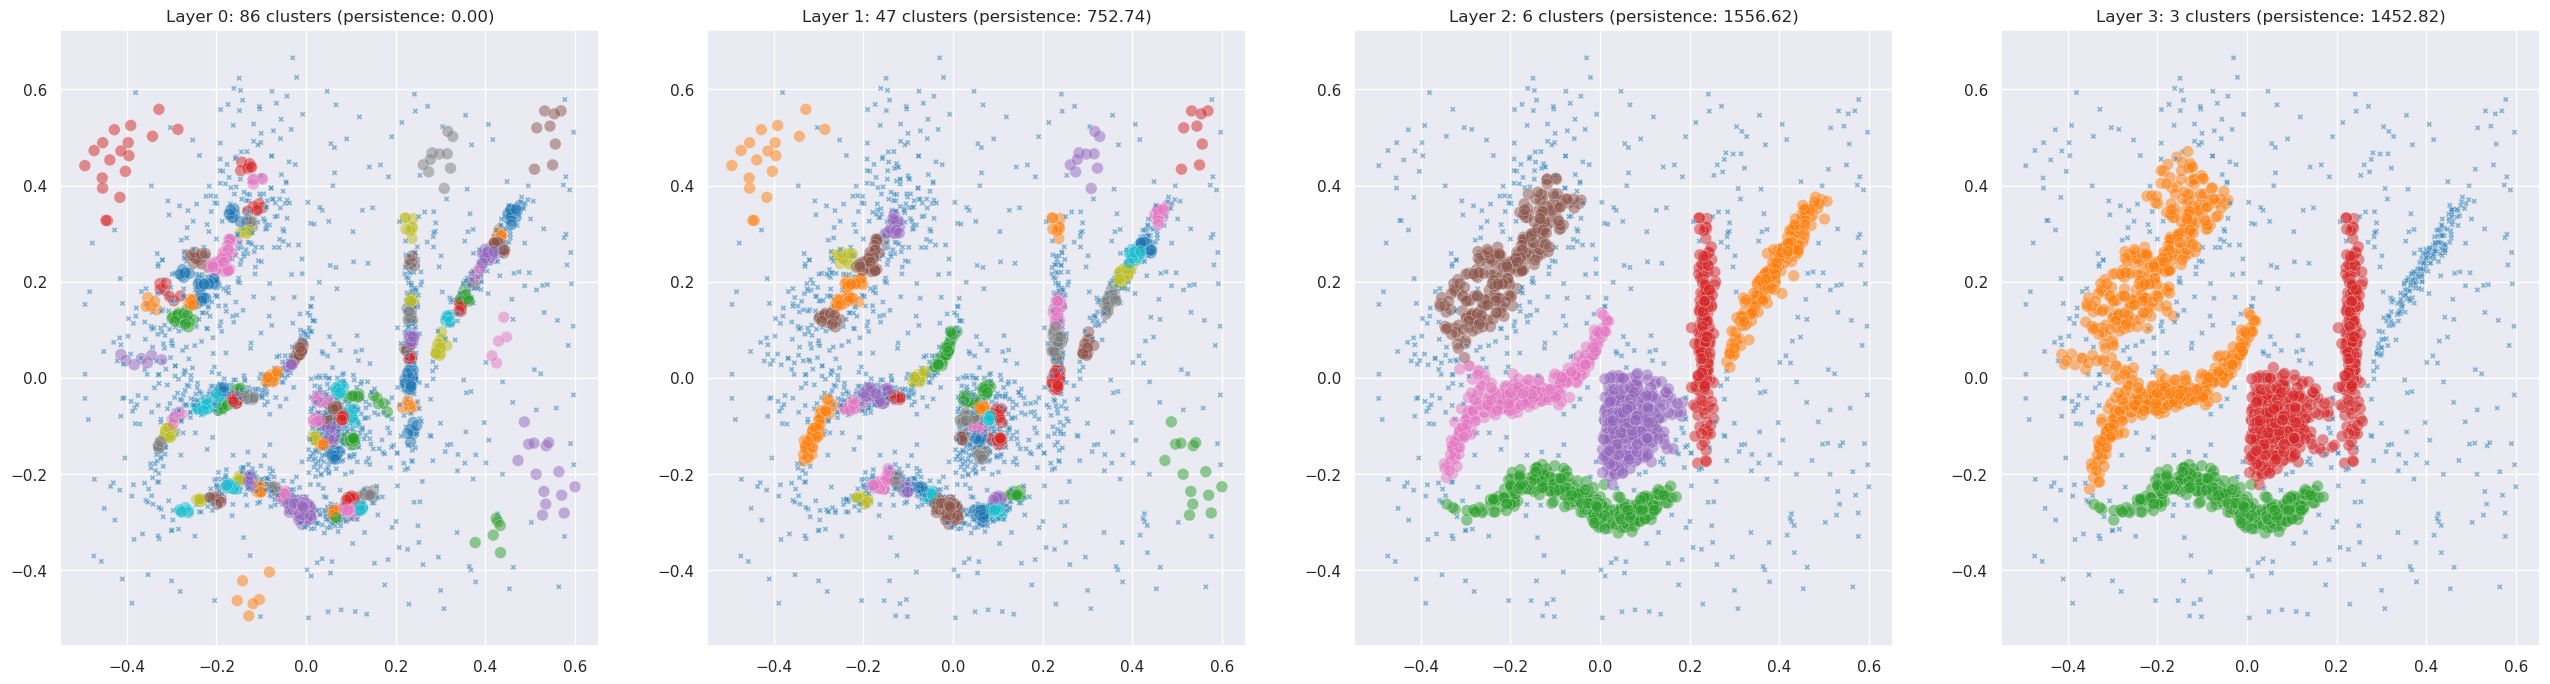

In [7]:
n_layers = len(clusterer.cluster_layers_)
fig, axes = plt.subplots(1, n_layers, figsize=(8 * n_layers, 8))
if n_layers == 1:
    axes = [axes]
for i, (ax, layer_labels) in enumerate(zip(axes, clusterer.cluster_layers_)):
    n_clusters = len(set(layer_labels[layer_labels >= 0]))
    sns.scatterplot(
        x=data.T[0], y=data.T[1], alpha=0.5,
        hue=layer_labels, style=layer_labels < 0, size=layer_labels < 0,
        palette="tab10", legend=False, ax=ax,
    )
    ax.set_title(f"Layer {i}: {n_clusters} clusters (persistence: {clusterer.layer_persistence_scores_[i]:.2f})")

For this particular dataset PLSCAN may find only one or two meaningful resolutions. That's itself informative -- it tells you there's really only one good scale of clustering in this data. To see PLSCAN really shine, we need data with genuine multi-scale structure.

## Multi-scale synthetic data

Let's build a dataset with nested structure: a few large macro-clusters, each of which contains tighter sub-clusters inside it. This kind of hierarchical structure is common in real-world data -- think of species within genera, or neighbourhoods within cities.

In [8]:
rng = np.random.RandomState(42)

# Macro-cluster centers, spread far apart
macro_centers = np.array([[0, 0], [12, 0], [6, 10]])

# Within each macro-cluster, place 2-3 sub-clusters
sub_offsets = [
    [[-1.5, -1], [1.5, -1], [0, 1.5]],   # 3 sub-clusters in macro 0
    [[-1.5, 0], [1.5, 0]],                 # 2 sub-clusters in macro 1
    [[-1, -1], [1, -1], [0, 1.5]],         # 3 sub-clusters in macro 2
]
sub_sizes = [
    [150, 150, 100],
    [200, 200],
    [150, 150, 100],
]

nested_data = []
for macro_center, offsets, sizes in zip(macro_centers, sub_offsets, sub_sizes):
    for offset, n in zip(offsets, sizes):
        center = macro_center + np.array(offset)
        nested_data.append(rng.normal(center, 0.5, size=(n, 2)))

nested_data = np.vstack(nested_data)

<Axes: >

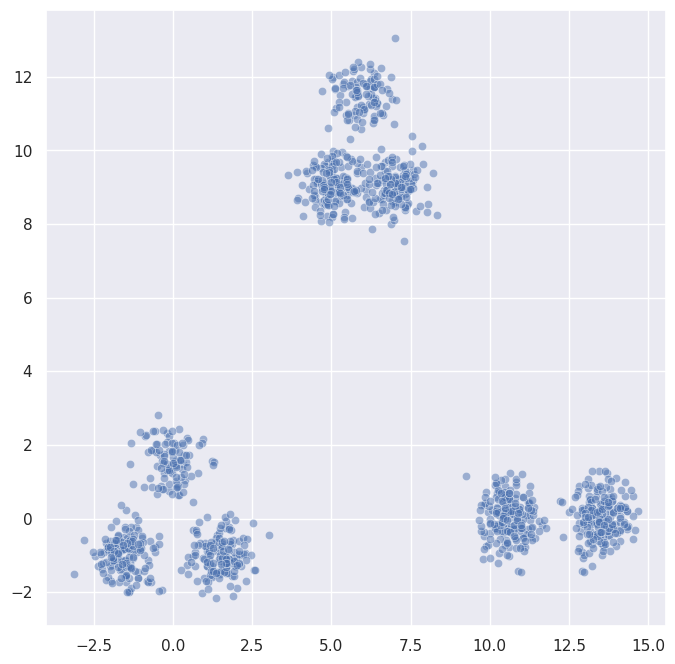

In [9]:
sns.scatterplot(x=nested_data.T[0], y=nested_data.T[1], alpha=0.5)

You can see three macro-clusters, and if you look closely each one contains smaller sub-clusters. Let's see what PLSCAN makes of this:

## PLSCAN on nested data

In [10]:
nested_clusterer = fast_hdbscan.PLSCAN()
nested_labels = nested_clusterer.fit_predict(nested_data)

In [11]:
print(f"Number of layers: {len(nested_clusterer.cluster_layers_)}")
print(f"Persistence scores: {nested_clusterer.layer_persistence_scores_}")

Number of layers: 4
Persistence scores: [0.0, np.float32(387.75885), np.float32(1050.1278), np.float32(1200.0)]


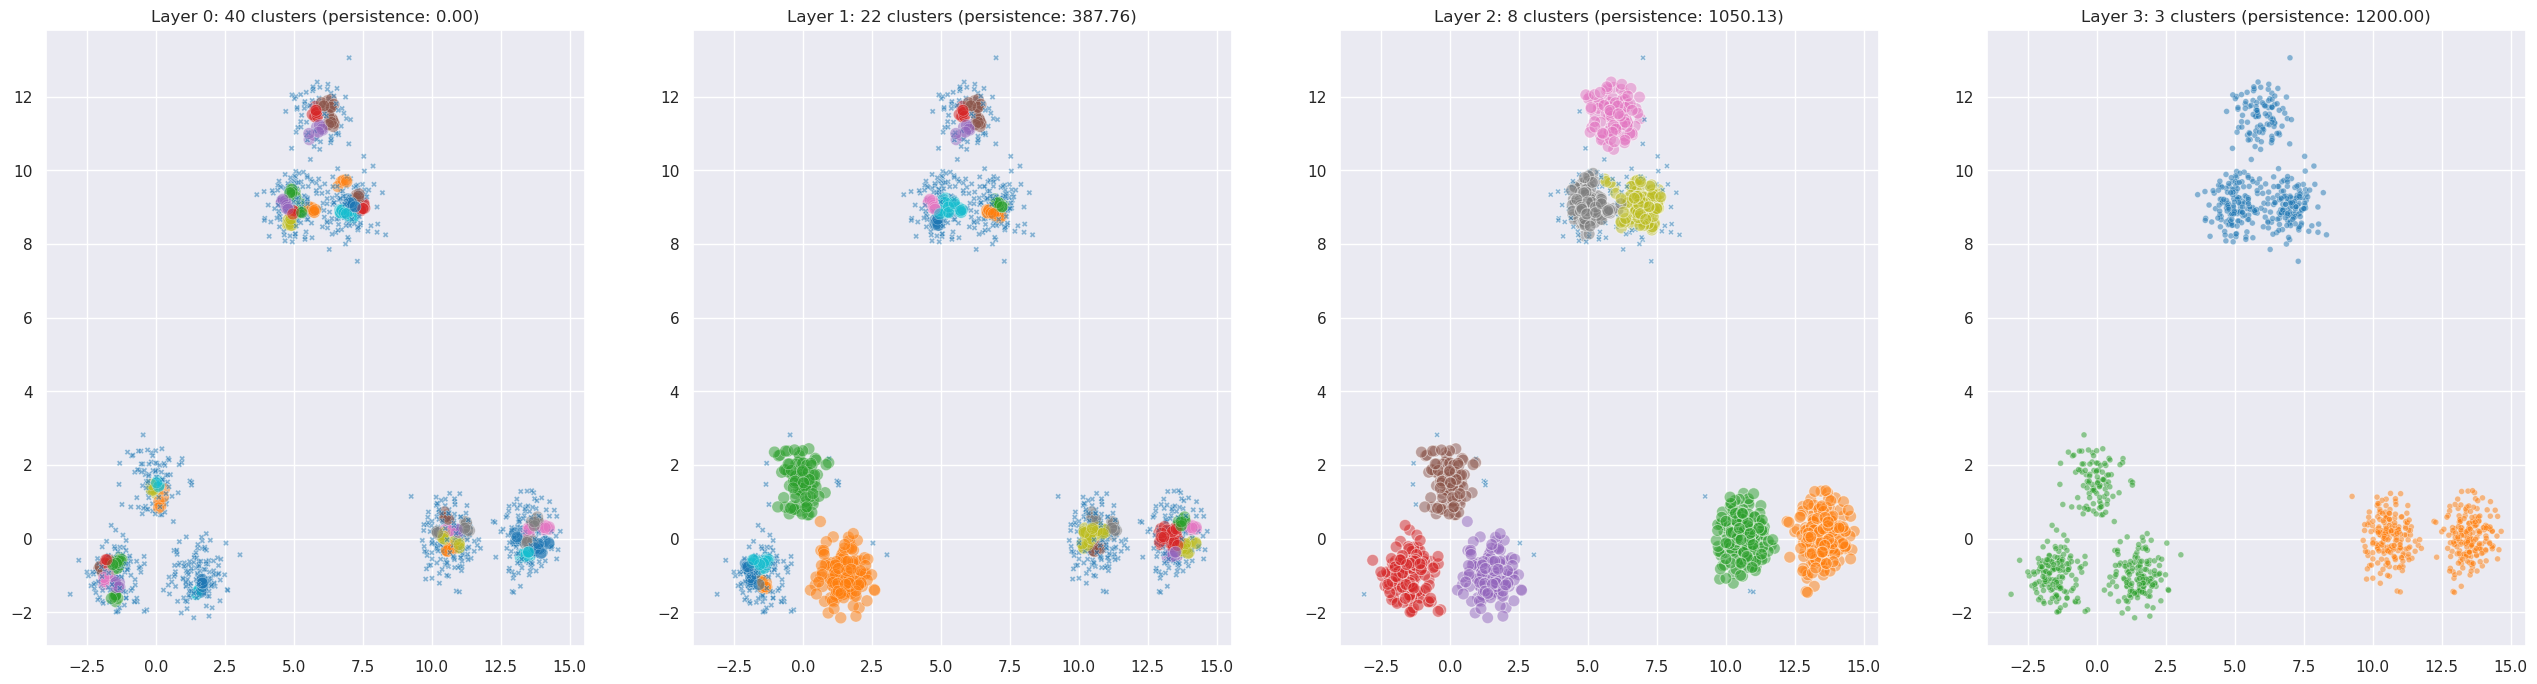

In [12]:
n_layers = len(nested_clusterer.cluster_layers_)
fig, axes = plt.subplots(1, n_layers, figsize=(8 * n_layers, 8))
if n_layers == 1:
    axes = [axes]
for i, (ax, layer_labels) in enumerate(zip(axes, nested_clusterer.cluster_layers_)):
    n_clusters = len(set(layer_labels[layer_labels >= 0]))
    sns.scatterplot(
        x=nested_data.T[0], y=nested_data.T[1], alpha=0.5,
        hue=layer_labels, style=layer_labels < 0, size=layer_labels < 0,
        palette="tab10", legend=False, ax=ax,
    )
    ax.set_title(f"Layer {i}: {n_clusters} clusters (persistence: {nested_clusterer.layer_persistence_scores_[i]:.2f})")

Now we can see PLSCAN in its element. It automatically found both the coarse structure (the macro-clusters) and the fine structure (the sub-clusters) without any manual parameter tuning. The persistence scores tell you how robust each resolution is.

## Persistence barcode

PLSCAN selects its layers by looking for peaks in a persistence score -- a function that measures how robust the clustering is at each possible resolution. We can plot this to see where the meaningful resolutions are:

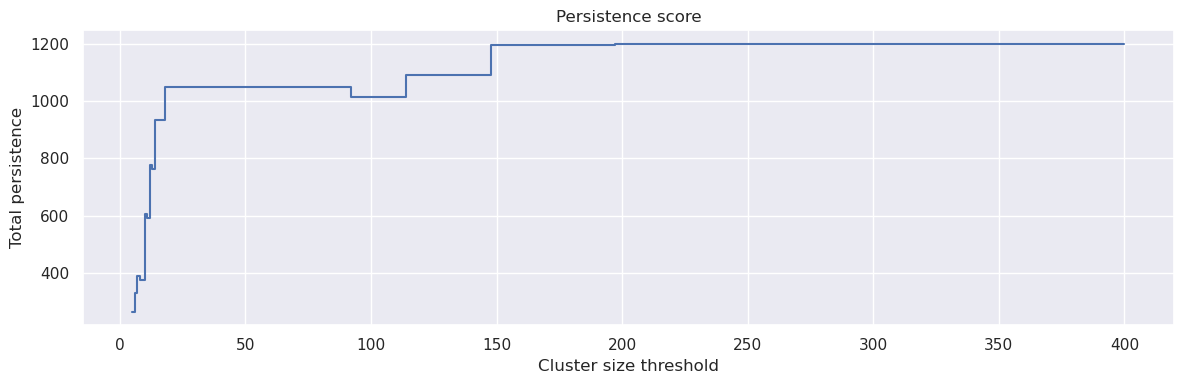

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    np.column_stack(
        (nested_clusterer.min_cluster_sizes_[:-1], nested_clusterer.min_cluster_sizes_[1:])
    ).reshape(-1),
    np.repeat(nested_clusterer.total_persistence_[:-1], 2),
)
ax.set_xlabel("Cluster size threshold")
ax.set_ylabel("Total persistence")
ax.set_title("Persistence score")
plt.tight_layout()

The peaks in this plot correspond to cluster resolutions that are particularly robust. PLSCAN automatically identifies these peaks and extracts a clustering at each one. The height of the peak corresponds to the persistence score -- higher peaks mean more robust clusterings.

## Cluster tree

When you have multiple layers, it's natural to ask how the clusters relate across resolutions. The ``cluster_tree_`` attribute provides this mapping. It is a dictionary where each key is a ``(layer, cluster_id)`` tuple representing a parent cluster, and the value is a list of ``(layer, cluster_id)`` tuples for its children at finer resolutions:

In [14]:
for parent, children in nested_clusterer.cluster_tree_.items():
    print(f"Layer {parent[0]}, Cluster {parent[1]} -> {[(f'Layer {c[0]}, Cluster {c[1]}') for c in children]}")

Layer 1, Cluster 0 -> ['Layer 0, Cluster 28', 'Layer 0, Cluster 29']
Layer 1, Cluster 1 -> ['Layer 0, Cluster 8', 'Layer 0, Cluster 0', 'Layer 0, Cluster 7']
Layer 1, Cluster 2 -> ['Layer 0, Cluster 2']
Layer 1, Cluster 3 -> ['Layer 0, Cluster 3']
Layer 1, Cluster 4 -> ['Layer 0, Cluster 4']
Layer 1, Cluster 5 -> ['Layer 0, Cluster 5']
Layer 1, Cluster 6 -> ['Layer 0, Cluster 6']
Layer 1, Cluster 7 -> ['Layer 0, Cluster 9']
Layer 1, Cluster 8 -> ['Layer 0, Cluster 11', 'Layer 0, Cluster 12']
Layer 1, Cluster 9 -> ['Layer 0, Cluster 15', 'Layer 0, Cluster 14']
Layer 1, Cluster 10 -> ['Layer 0, Cluster 13']
Layer 1, Cluster 11 -> ['Layer 0, Cluster 16']
Layer 1, Cluster 12 -> ['Layer 0, Cluster 25', 'Layer 0, Cluster 26', 'Layer 0, Cluster 19']
Layer 1, Cluster 13 -> ['Layer 0, Cluster 18']
Layer 1, Cluster 14 -> ['Layer 0, Cluster 20']
Layer 1, Cluster 15 -> ['Layer 0, Cluster 23']
Layer 1, Cluster 16 -> ['Layer 0, Cluster 24']
Layer 1, Cluster 17 -> ['Layer 0, Cluster 33', 'Layer 0, Cl

This tells you exactly which coarse-grained clusters split into which fine-grained sub-clusters, giving you a hierarchical view of the structure in your data.

## Parameter tuning

While PLSCAN works well with default parameters, there are a few knobs you can turn:

- `base_min_cluster_size` controls the finest resolution explored. Smaller values allow PLSCAN to find smaller clusters. The default of 10 works well for most datasets.
- `base_n_clusters` is an alternative to `base_min_cluster_size`. If set, PLSCAN will binary search for a `min_cluster_size` that produces approximately this many clusters in the base layer.
- `max_layers` caps how many layers PLSCAN will return. The default of 10 is generous; most datasets have far fewer meaningful resolutions.
- `layer_similarity_threshold` controls how diverse the returned layers need to be. Higher values mean fewer, more distinct layers; lower values allow more similar layers through. The default of 0.2 is a good starting point.
- `min_samples` plays the same role as in HDBSCAN -- it controls the density estimation. If not set, it defaults to `min_samples=5`.

Let's see the effect of ``layer_similarity_threshold`` on our nested data:

In [21]:
for threshold in [0.0, 0.25, 0.5]:
    plscan = fast_hdbscan.PLSCAN(layer_similarity_threshold=threshold)
    plscan.fit(nested_data)
    n_layers = len(plscan.cluster_layers_)
    n_clusters_per_layer = [len(set(l[l >= 0])) for l in plscan.cluster_layers_]
    print(f"threshold={threshold}: {n_layers} layers with {n_clusters_per_layer} clusters each")

threshold=0.0: 3 layers with [40, 8, 3] clusters each
threshold=0.25: 4 layers with [40, 15, 8, 3] clusters each
threshold=0.5: 6 layers with [40, 22, 15, 11, 8, 3] clusters each


Higher thresholds allow more similar layers through, so you tend to get more layers. Lower thresholds are more selective, keeping only the most distinct resolutions.

## Citing

If you use PLSCAN in your work please cite the paper:

```bibtex
@article{plscan2024,
    title   = {{Persistent Multiscale Density-based Clustering}},
    year    = {2024},
    eprint  = {2512.16558},
    archivePrefix = {arXiv},
    primaryClass  = {cs.LG},
    url     = {https://arxiv.org/abs/2512.16558},
}
```